## Mount Drive and create init python script

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!touch /content/drive/MyDrive/MRP/codes/src/__init__.py

## Dataset Path

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/MRP/codes")

sys.path.append(str(PROJECT_ROOT))

In [ ]:
binary_path = PROJECT_ROOT / "data" / "diabetes_binary_health_indicators_BRFSS2015.csv"
multi_path = PROJECT_ROOT / "data" / "diabetes_012_health_indicators_BRFSS2015.csv"

## Data Preprocessing

In [ ]:
import pandas as pd
from src.preprocessing import prepare_modeling_data, print_class_distribution

binary_df = pd.read_csv(binary_path)
multi_df = pd.read_csv(multi_path)

X_train_bin, X_test_bin, y_train_bin, y_test_bin = prepare_modeling_data(
    binary_df,
    target_col="Diabetes_binary"
)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = prepare_modeling_data(
    multi_df,
    target_col="Diabetes_012"
)

print_class_distribution(y_train_bin, "Binary Train")
print_class_distribution(y_test_bin, "Binary Test")

print_class_distribution(y_train_multi, "Multiclass Train")
print_class_distribution(y_test_multi, "Multiclass Test")


Class distribution for Binary Train:
                  count  percentage
Diabetes_binary                    
0.0              174667       86.07
1.0               28277       13.93

Class distribution for Binary Test:
                 count  percentage
Diabetes_binary                   
0.0              43667       86.07
1.0               7069       13.93

Class distribution for Multiclass Train:
               count  percentage
Diabetes_012                    
0.0           170962       84.24
1.0             3705        1.83
2.0            28277       13.93

Class distribution for Multiclass Test:
              count  percentage
Diabetes_012                   
0.0           42741       84.24
1.0             926        1.83
2.0            7069       13.93


## Baseline Logistic Regression Modeling

After preparing stratified train-test splits, the first modeling step is to train baseline Logistic Regression models. Logistic Regression is used as an initial interpretable baseline before training more complex models such as Random Forest and XGBoost.

Because Logistic Regression is sensitive to feature scale, feature standardization is applied inside the model pipeline.

In [ ]:
from src.baseline_models import build_logistic_regression_model, train_model

### Binary Logistic Regression Baseline

The binary model predicts whether a respondent belongs to the no-diabetes class or the combined prediabetes/diabetes class.

In [ ]:
binary_lr_model = build_logistic_regression_model(
    task_type="binary",
    class_weight=None,
    random_state=42
)

binary_lr_model = train_model(
    model=binary_lr_model,
    X_train=X_train_bin,
    y_train=y_train_bin
)

print("Binary Logistic Regression model trained successfully.")

Binary Logistic Regression model trained successfully.


### Multiclass Logistic Regression Baseline

The multiclass model predicts three classes: no diabetes, prediabetes, and diabetes.

In [ ]:
multiclass_lr_model = build_logistic_regression_model(
    task_type="multiclass",
    class_weight=None,
    random_state=42
)

multiclass_lr_model = train_model(
    model=multiclass_lr_model,
    X_train=X_train_multi,
    y_train=y_train_multi
)

print("Multiclass Logistic Regression model trained successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Multiclass Logistic Regression model trained successfully.


## Baseline Logistic Regression Evaluation

After training the baseline Logistic Regression models, the next step is to evaluate their performance on the held-out test sets. For the binary dataset, accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrix are reported. For the multiclass dataset, macro-averaged precision, recall, and F1-score are used because the prediabetes class is highly underrepresented.

In [ ]:

from src.baseline_evaluation import (
    evaluate_binary_model,
    evaluate_multiclass_model,
    summarize_results
)

### Binary Logistic Regression Evaluation

In [ ]:
binary_lr_results = evaluate_binary_model(
    model=binary_lr_model,
    X_test=X_test_bin,
    y_test=y_test_bin
)

binary_lr_summary = summarize_results(binary_lr_results)
binary_lr_summary

,accuracy,precision,recall,f1_score,roc_auc
0,0.862129,0.517098,0.158297,0.242391,0.819163


In [ ]:
print("Binary Logistic Regression Classification Report:")
print(binary_lr_results["classification_report"])

print("Binary Logistic Regression Confusion Matrix:")
print(binary_lr_results["confusion_matrix"])

Binary Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.92     43667
         1.0       0.52      0.16      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.57      0.58     50736
weighted avg       0.83      0.86      0.83     50736

Binary Logistic Regression Confusion Matrix:
[[42622  1045]
 [ 5950  1119]]


### Multiclass Logistic Regression Evaluation

In [ ]:
multiclass_lr_results = evaluate_multiclass_model(
    model=multiclass_lr_model,
    X_test=X_test_multi,
    y_test=y_test_multi
)

multiclass_lr_summary = summarize_results(multiclass_lr_results)
multiclass_lr_summary

,accuracy,precision_macro,recall_macro,f1_macro
0,0.845475,0.458692,0.38291,0.391581


In [ ]:
print("Multiclass Logistic Regression Classification Report:")
print(multiclass_lr_results["classification_report"])

print("Multiclass Logistic Regression Confusion Matrix:")
print(multiclass_lr_results["confusion_matrix"])

Multiclass Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.51      0.17      0.26      7069

    accuracy                           0.85     50736
   macro avg       0.46      0.38      0.39     50736
weighted avg       0.80      0.85      0.81     50736

Multiclass Logistic Regression Confusion Matrix:
[[41667     0  1074]
 [  839     0    87]
 [ 5840     0  1229]]


## Logistic Regression with Class Weights

The baseline Logistic Regression models showed high overall accuracy, but weak recall for diabetes-related minority classes. This is expected because both datasets are imbalanced, especially the multiclass dataset where prediabetes represents only 1.83% of observations.

To address this, Logistic Regression is retrained using `class_weight="balanced"`. This gives higher penalty to mistakes on minority classes and helps evaluate whether class weighting improves recall for prediabetes and diabetes.

In [ ]:
from src.baseline_evaluation_balanced import build_logistic_regression_model, train_model
from src.baseline_evaluation import (
    evaluate_binary_model,
    evaluate_multiclass_model,
    summarize_results
)

### Binary Logistic Regression with Class Weights

In [ ]:
binary_lr_balanced_model = build_logistic_regression_model(
    task_type="binary",
    class_weight="balanced",
    random_state=42
)

binary_lr_balanced_model = train_model(
    model=binary_lr_balanced_model,
    X_train=X_train_bin,
    y_train=y_train_bin
)

print("Balanced Binary Logistic Regression model trained successfully.")

Balanced Binary Logistic Regression model trained successfully.


In [ ]:
binary_lr_balanced_results = evaluate_binary_model(
    model=binary_lr_balanced_model,
    X_test=X_test_bin,
    y_test=y_test_bin
)

binary_lr_balanced_summary = summarize_results(binary_lr_balanced_results)
binary_lr_balanced_summary

,accuracy,precision,recall,f1_score,roc_auc
0,0.731512,0.310749,0.761069,0.441309,0.819631


In [ ]:
print("Balanced Binary Logistic Regression Classification Report:")
print(binary_lr_balanced_results["classification_report"])

print("Balanced Binary Logistic Regression Confusion Matrix:")
print(binary_lr_balanced_results["confusion_matrix"])

Balanced Binary Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.82     43667
         1.0       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736

Balanced Binary Logistic Regression Confusion Matrix:
[[31734 11933]
 [ 1689  5380]]


###  Multiclass Logistic Regression with Class Weights

In [ ]:
multiclass_lr_balanced_model = build_logistic_regression_model(
    task_type="multiclass",
    class_weight="balanced",
    random_state=42
)

multiclass_lr_balanced_model = train_model(
    model=multiclass_lr_balanced_model,
    X_train=X_train_multi,
    y_train=y_train_multi
)

print("Balanced Multiclass Logistic Regression model trained successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Balanced Multiclass Logistic Regression model trained successfully.


In [ ]:
multiclass_lr_balanced_results = evaluate_multiclass_model(
    model=multiclass_lr_balanced_model,
    X_test=X_test_multi,
    y_test=y_test_multi
)

multiclass_lr_balanced_summary = summarize_results(multiclass_lr_balanced_results)
multiclass_lr_balanced_summary

,accuracy,precision_macro,recall_macro,f1_macro
0,0.645754,0.445639,0.524173,0.426883


In [ ]:
print("Balanced Multiclass Logistic Regression Classification Report:")
print(multiclass_lr_balanced_results["classification_report"])

print("Balanced Multiclass Logistic Regression Confusion Matrix:")
print(multiclass_lr_balanced_results["confusion_matrix"])

Balanced Multiclass Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.66      0.78     42741
         1.0       0.03      0.33      0.06       926
         2.0       0.35      0.58      0.44      7069

    accuracy                           0.65     50736
   macro avg       0.45      0.52      0.43     50736
weighted avg       0.85      0.65      0.72     50736

Balanced Multiclass Logistic Regression Confusion Matrix:
[[28337  7239  7165]
 [  240   302   384]
 [ 1219  1726  4124]]


### Baseline vs Class-Weighted Logistic Regression Comparison

The baseline and class-weighted Logistic Regression models are compared to examine the effect of imbalance handling. The main focus is not only accuracy, but also recall and macro-F1, because minority-class detection is important for diabetes and prediabetes screening.

In [ ]:
binary_lr_summary["model"] = "Baseline Logistic Regression"
binary_lr_balanced_summary["model"] = "Balanced Logistic Regression"

binary_lr_comparison = pd.concat(
    [binary_lr_summary, binary_lr_balanced_summary],
    ignore_index=True
)

binary_lr_comparison = binary_lr_comparison[
    ["model", "accuracy", "precision", "recall", "f1_score", "roc_auc"]
]

binary_lr_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
0,Baseline Logistic Regression,0.862129,0.517098,0.158297,0.242391,0.819163
1,Balanced Logistic Regression,0.731512,0.310749,0.761069,0.441309,0.819631


In [ ]:
multiclass_lr_summary["model"] = "Baseline Logistic Regression"
multiclass_lr_balanced_summary["model"] = "Balanced Logistic Regression"

multiclass_lr_comparison = pd.concat(
    [multiclass_lr_summary, multiclass_lr_balanced_summary],
    ignore_index=True
)

multiclass_lr_comparison = multiclass_lr_comparison[
    ["model", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
]

multiclass_lr_comparison

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Baseline Logistic Regression,0.845475,0.458692,0.382910,0.391581
1,Balanced Logistic Regression,0.645754,0.445639,0.524173,0.426883


## Random Forest Baseline Modeling

After evaluating Logistic Regression, the next model is Random Forest. Random Forest is a nonlinear ensemble learning method that combines multiple decision trees. Unlike Logistic Regression, Random Forest does not require feature scaling and can capture nonlinear relationships between BRFSS health indicators and diabetes status.

In this step, baseline Random Forest models are trained on the full feature set without class weighting. These results will later be compared with class-weighted Random Forest models.

In [ ]:
from src.random_forest_baseline import build_random_forest_model, train_random_forest_model

###  Binary Random Forest Baseline

In [ ]:
binary_rf_model = build_random_forest_model(
    class_weight=None,
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

binary_rf_model = train_random_forest_model(
    model=binary_rf_model,
    X_train=X_train_bin,
    y_train=y_train_bin
)

print("Binary Random Forest baseline model trained successfully.")

Binary Random Forest baseline model trained successfully.


In [ ]:
binary_rf_results = evaluate_binary_model(
    model=binary_rf_model,
    X_test=X_test_bin,
    y_test=y_test_bin
)

binary_rf_summary = summarize_results(binary_rf_results)
binary_rf_summary

,accuracy,precision,recall,f1_score,roc_auc
0,0.859705,0.490328,0.175697,0.258696,0.796921


In [ ]:
print("Binary Random Forest Classification Report:")
print(binary_rf_results["classification_report"])

print("Binary Random Forest Confusion Matrix:")
print(binary_rf_results["confusion_matrix"])

Binary Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43667
         1.0       0.49      0.18      0.26      7069

    accuracy                           0.86     50736
   macro avg       0.68      0.57      0.59     50736
weighted avg       0.82      0.86      0.83     50736

Binary Random Forest Confusion Matrix:
[[42376  1291]
 [ 5827  1242]]


### Multiclass Random Forest Baseline

In [ ]:
multiclass_rf_model = build_random_forest_model(
    class_weight=None,
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

multiclass_rf_model = train_random_forest_model(
    model=multiclass_rf_model,
    X_train=X_train_multi,
    y_train=y_train_multi
)

print("Multiclass Random Forest baseline model trained successfully.")

Multiclass Random Forest baseline model trained successfully.


In [ ]:
multiclass_rf_results = evaluate_multiclass_model(
    model=multiclass_rf_model,
    X_test=X_test_multi,
    y_test=y_test_multi
)

multiclass_rf_summary = summarize_results(multiclass_rf_results)
multiclass_rf_summary

,accuracy,precision_macro,recall_macro,f1_macro
0,0.843504,0.454903,0.388309,0.398429


In [ ]:
print("Multiclass Random Forest Classification Report:")
print(multiclass_rf_results["classification_report"])

print("Multiclass Random Forest Confusion Matrix:")
print(multiclass_rf_results["confusion_matrix"])

Multiclass Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.50      0.20      0.28      7069

    accuracy                           0.84     50736
   macro avg       0.45      0.39      0.40     50736
weighted avg       0.80      0.84      0.81     50736

Multiclass Random Forest Confusion Matrix:
[[41410    42  1289]
 [  832     0    94]
 [ 5677     6  1386]]


## Random Forest with Class Weights

The baseline Random Forest models showed high overall accuracy but weak recall for diabetes-related minority classes. In particular, the multiclass Random Forest failed to detect the prediabetes class. To address this class imbalance issue, Random Forest models are retrained using `class_weight="balanced"`.

This setting gives higher weight to minority classes during training and helps evaluate whether class weighting improves recall for diabetes and prediabetes compared with the baseline Random Forest model.

In [ ]:
from src.random_forest_balanced import (
    build_balanced_random_forest_model,
    train_balanced_random_forest_model
)

### Binary Random Forest with Class Weights

In [ ]:
binary_rf_balanced_model = build_balanced_random_forest_model(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

binary_rf_balanced_model = train_balanced_random_forest_model(
    model=binary_rf_balanced_model,
    X_train=X_train_bin,
    y_train=y_train_bin
)

print("Balanced Binary Random Forest model trained successfully.")

Balanced Binary Random Forest model trained successfully.


In [ ]:
binary_rf_balanced_results = evaluate_binary_model(
    model=binary_rf_balanced_model,
    X_test=X_test_bin,
    y_test=y_test_bin
)

binary_rf_balanced_summary = summarize_results(
    binary_rf_balanced_results
)

binary_rf_balanced_summary

,accuracy,precision,recall,f1_score,roc_auc
0,0.856827,0.459051,0.154619,0.231323,0.794689


In [ ]:
print("Balanced Binary Random Forest Classification Report:")
print(binary_rf_balanced_results["classification_report"])

print("Balanced Binary Random Forest Confusion Matrix:")
print(binary_rf_balanced_results["confusion_matrix"])

Balanced Binary Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43667
         1.0       0.46      0.15      0.23      7069

    accuracy                           0.86     50736
   macro avg       0.67      0.56      0.58     50736
weighted avg       0.82      0.86      0.82     50736

Balanced Binary Random Forest Confusion Matrix:
[[42379  1288]
 [ 5976  1093]]


### Multiclass Random Forest with Class Weights

In [ ]:
multiclass_rf_balanced_model = build_balanced_random_forest_model(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

multiclass_rf_balanced_model = train_balanced_random_forest_model(
    model=multiclass_rf_balanced_model,
    X_train=X_train_multi,
    y_train=y_train_multi
)

print("Balanced Multiclass Random Forest model trained successfully.")

Balanced Multiclass Random Forest model trained successfully.


In [ ]:
multiclass_rf_balanced_results = evaluate_multiclass_model(
    model=multiclass_rf_balanced_model,
    X_test=X_test_multi,
    y_test=y_test_multi
)

multiclass_rf_balanced_summary = summarize_results(
    multiclass_rf_balanced_results
)

multiclass_rf_balanced_summary

,accuracy,precision_macro,recall_macro,f1_macro
0,0.83901,0.444946,0.375669,0.382425


In [ ]:
print("Balanced Multiclass Random Forest Classification Report:")
print(multiclass_rf_balanced_results["classification_report"])

print("Balanced Multiclass Random Forest Confusion Matrix:")
print(multiclass_rf_balanced_results["confusion_matrix"])

Balanced Multiclass Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.48      0.16      0.24      7069

    accuracy                           0.84     50736
   macro avg       0.44      0.38      0.38     50736
weighted avg       0.79      0.84      0.80     50736

Balanced Multiclass Random Forest Confusion Matrix:
[[41458   128  1155]
 [  858     0    68]
 [ 5944    15  1110]]


###  Baseline versus Class-Weighted Random Forest Comparison

To evaluate the impact of class weighting, the baseline and class-weighted Random Forest models are compared. Particular attention is given to recall and F1-score because these metrics better reflect minority-class detection performance than overall accuracy.

In [ ]:
binary_rf_summary["model"] = "Baseline Random Forest"
binary_rf_balanced_summary["model"] = "Balanced Random Forest"

binary_rf_comparison = pd.concat(
    [binary_rf_summary, binary_rf_balanced_summary],
    ignore_index=True
)

binary_rf_comparison = binary_rf_comparison[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ]
]

binary_rf_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
0,Baseline Random Forest,0.859705,0.490328,0.175697,0.258696,0.796921
1,Balanced Random Forest,0.856827,0.459051,0.154619,0.231323,0.794689


In [ ]:
multiclass_rf_summary["model"] = "Baseline Random Forest"
multiclass_rf_balanced_summary["model"] = "Balanced Random Forest"

multiclass_rf_comparison = pd.concat(
    [multiclass_rf_summary, multiclass_rf_balanced_summary],
    ignore_index=True
)

multiclass_rf_comparison = multiclass_rf_comparison[
    [
        "model",
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro"
    ]
]

multiclass_rf_comparison

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Baseline Random Forest,0.843504,0.454903,0.388309,0.398429
1,Balanced Random Forest,0.839010,0.444946,0.375669,0.382425


##  XGBoost Baseline Modeling

After Logistic Regression and Random Forest, the next model is XGBoost. XGBoost is a gradient boosting algorithm that builds trees sequentially, where each new tree attempts to correct the errors of the previous trees.

XGBoost is included because it often performs well on structured tabular datasets and can capture nonlinear relationships among health, demographic, behavioral, and lifestyle indicators. In this step, baseline XGBoost models are trained on the full feature set without imbalance handling.

In [ ]:
from src.xgboost_baseline import build_xgboost_model, train_xgboost_model

### Binary XGBoost Baseline

In [ ]:
binary_xgb_model = build_xgboost_model(
    task_type="binary",
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

binary_xgb_model = train_xgboost_model(
    model=binary_xgb_model,
    X_train=X_train_bin,
    y_train=y_train_bin
)

print("Binary XGBoost baseline model trained successfully.")

Binary XGBoost baseline model trained successfully.


In [ ]:
binary_xgb_results = evaluate_binary_model(
    model=binary_xgb_model,
    X_test=X_test_bin,
    y_test=y_test_bin
)

binary_xgb_summary = summarize_results(binary_xgb_results)
binary_xgb_summary

,accuracy,precision,recall,f1_score,roc_auc
0,0.865776,0.561345,0.167633,0.25817,0.827816


In [ ]:
print("Binary XGBoost Classification Report:")
print(binary_xgb_results["classification_report"])

print("Binary XGBoost Confusion Matrix:")
print(binary_xgb_results["confusion_matrix"])

Binary XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     43667
         1.0       0.56      0.17      0.26      7069

    accuracy                           0.87     50736
   macro avg       0.72      0.57      0.59     50736
weighted avg       0.83      0.87      0.83     50736

Binary XGBoost Confusion Matrix:
[[42741   926]
 [ 5884  1185]]


### Multiclass XGBoost Baseline

In [ ]:
multiclass_xgb_model = build_xgboost_model(
    task_type="multiclass",
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

multiclass_xgb_model = train_xgboost_model(
    model=multiclass_xgb_model,
    X_train=X_train_multi,
    y_train=y_train_multi
)

print("Multiclass XGBoost baseline model trained successfully.")

Multiclass XGBoost baseline model trained successfully.


In [ ]:
multiclass_xgb_results = evaluate_multiclass_model(
    model=multiclass_xgb_model,
    X_test=X_test_multi,
    y_test=y_test_multi
)

multiclass_xgb_summary = summarize_results(multiclass_xgb_results)
multiclass_xgb_summary

,accuracy,precision_macro,recall_macro,f1_macro
0,0.849712,0.474643,0.387853,0.398707


In [ ]:
print("Multiclass XGBoost Classification Report:")
print(multiclass_xgb_results["classification_report"])

print("Multiclass XGBoost Confusion Matrix:")
print(multiclass_xgb_results["confusion_matrix"])

Multiclass XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.56      0.19      0.28      7069

    accuracy                           0.85     50736
   macro avg       0.47      0.39      0.40     50736
weighted avg       0.81      0.85      0.81     50736

Multiclass XGBoost Confusion Matrix:
[[41799     0   942]
 [  838     0    88]
 [ 5757     0  1312]]


##  XGBoost with Imbalance Handling

The baseline XGBoost models showed strong overall accuracy, but they still performed poorly on minority diabetes-related classes, especially the prediabetes class in the multiclass dataset. To address this issue, imbalance-aware XGBoost models are trained.

For the binary dataset, `scale_pos_weight` is used to increase the importance of the positive diabetes/prediabetes class. For the multiclass dataset, sample weights are computed using class frequencies and passed during training. This allows the model to give greater attention to minority classes while still using the original training data.

In [ ]:
from src.xgboost_balanced import (
    calculate_binary_scale_pos_weight,
    build_balanced_binary_xgboost_model,
    build_balanced_multiclass_xgboost_model,
    compute_multiclass_sample_weights,
    train_xgboost_model
)

###  Binary XGBoost with `scale_pos_weight`

In [ ]:
binary_scale_pos_weight = calculate_binary_scale_pos_weight(y_train_bin)

print(f"Binary scale_pos_weight: {binary_scale_pos_weight:.4f}")

Binary scale_pos_weight: 6.1770


In [ ]:
binary_xgb_balanced_model = build_balanced_binary_xgboost_model(
    scale_pos_weight=binary_scale_pos_weight,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

binary_xgb_balanced_model = train_xgboost_model(
    model=binary_xgb_balanced_model,
    X_train=X_train_bin,
    y_train=y_train_bin
)

print("Balanced Binary XGBoost model trained successfully.")

Balanced Binary XGBoost model trained successfully.


In [ ]:
binary_xgb_balanced_results = evaluate_binary_model(
    model=binary_xgb_balanced_model,
    X_test=X_test_bin,
    y_test=y_test_bin
)

binary_xgb_balanced_summary = summarize_results(binary_xgb_balanced_results)

binary_xgb_balanced_summary

,accuracy,precision,recall,f1_score,roc_auc
0,0.721756,0.307115,0.793747,0.442875,0.827355


In [ ]:
print("Balanced Binary XGBoost Classification Report:")
print(binary_xgb_balanced_results["classification_report"])

print("Balanced Binary XGBoost Confusion Matrix:")
print(binary_xgb_balanced_results["confusion_matrix"])

Balanced Binary XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.71      0.81     43667
         1.0       0.31      0.79      0.44      7069

    accuracy                           0.72     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.72      0.76     50736

Balanced Binary XGBoost Confusion Matrix:
[[31008 12659]
 [ 1458  5611]]


###  Multiclass XGBoost with Sample Weights

In [ ]:
multiclass_sample_weights = compute_multiclass_sample_weights(y_train_multi)

print("Multiclass sample weights computed successfully.")

Multiclass sample weights computed successfully.


In [ ]:
multiclass_xgb_balanced_model = build_balanced_multiclass_xgboost_model(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

multiclass_xgb_balanced_model = train_xgboost_model(
    model=multiclass_xgb_balanced_model,
    X_train=X_train_multi,
    y_train=y_train_multi,
    sample_weight=multiclass_sample_weights
)

print("Balanced Multiclass XGBoost model trained successfully.")

Balanced Multiclass XGBoost model trained successfully.


In [ ]:
multiclass_xgb_balanced_results = evaluate_multiclass_model(
    model=multiclass_xgb_balanced_model,
    X_test=X_test_multi,
    y_test=y_test_multi
)

multiclass_xgb_balanced_summary = summarize_results(multiclass_xgb_balanced_results)

multiclass_xgb_balanced_summary

,accuracy,precision_macro,recall_macro,f1_macro
0,0.624152,0.443809,0.52307,0.419565


###  Baseline versus Balanced XGBoost Comparison

The baseline and imbalance-aware XGBoost models are compared to examine whether class-weighting strategies improve minority-class detection. For the binary dataset, recall for the positive diabetes/prediabetes class is especially important. For the multiclass dataset, the focus is on macro recall, macro F1-score, and the recall of the prediabetes class.

In [ ]:
binary_xgb_summary["model"] = "Baseline XGBoost"
binary_xgb_balanced_summary["model"] = "Balanced XGBoost"

binary_xgb_comparison = pd.concat(
    [binary_xgb_summary, binary_xgb_balanced_summary],
    ignore_index=True
)

binary_xgb_comparison = binary_xgb_comparison[
    ["model", "accuracy", "precision", "recall", "f1_score", "roc_auc"]
]

binary_xgb_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
0,Baseline XGBoost,0.865776,0.561345,0.167633,0.258170,0.827816
1,Balanced XGBoost,0.721756,0.307115,0.793747,0.442875,0.827355


In [ ]:
multiclass_xgb_summary["model"] = "Baseline XGBoost"
multiclass_xgb_balanced_summary["model"] = "Balanced XGBoost"

multiclass_xgb_comparison = pd.concat(
    [multiclass_xgb_summary, multiclass_xgb_balanced_summary],
    ignore_index=True
)

multiclass_xgb_comparison = multiclass_xgb_comparison[
    ["model", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
]

multiclass_xgb_comparison

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Baseline XGBoost,0.849712,0.474643,0.387853,0.398707
1,Balanced XGBoost,0.624152,0.443809,0.523070,0.419565


## SMOTE-Based Imbalance Handling

After evaluating baseline and class-weighted models, SMOTE is applied as an additional imbalance-handling strategy. SMOTE creates synthetic samples for minority classes in the training data.

To avoid data leakage, SMOTE is applied only to the training set. The test set remains unchanged so that model performance is evaluated on the original real-world class distribution.

In [ ]:
from src.smote_preprocessing import apply_smote

### Apply SMOTE to Binary Training Data

In [ ]:
X_train_bin_smote, y_train_bin_smote = apply_smote(
    X_train=X_train_bin,
    y_train=y_train_bin,
    random_state=42
)

print_class_distribution(y_train_bin_smote, "Binary Train After SMOTE")


Class distribution for Binary Train After SMOTE:
                  count  percentage
Diabetes_binary                    
0.0              174667        50.0
1.0              174667        50.0


### Apply SMOTE to Multiclass Training Data

In [ ]:
X_train_multi_smote, y_train_multi_smote = apply_smote(
    X_train=X_train_multi,
    y_train=y_train_multi,
    random_state=42
)

print_class_distribution(y_train_multi_smote, "Multiclass Train After SMOTE")


Class distribution for Multiclass Train After SMOTE:
               count  percentage
Diabetes_012                    
0.0           170962       33.33
1.0           170962       33.33
2.0           170962       33.33


## Logistic Regression with SMOTE

Logistic Regression is first trained on SMOTE-resampled data to evaluate whether synthetic minority oversampling improves minority-class detection compared with baseline and class-weighted Logistic Regression.

In [ ]:
binary_lr_smote_model = build_logistic_regression_model(
    task_type="binary",
    class_weight=None,
    random_state=42
)

binary_lr_smote_model = train_model(
    model=binary_lr_smote_model,
    X_train=X_train_bin_smote,
    y_train=y_train_bin_smote
)

print("Binary Logistic Regression with SMOTE trained successfully.")

Binary Logistic Regression with SMOTE trained successfully.


In [ ]:
binary_lr_smote_results = evaluate_binary_model(
    model=binary_lr_smote_model,
    X_test=X_test_bin,
    y_test=y_test_bin
)

binary_lr_smote_summary = summarize_results(binary_lr_smote_results)
binary_lr_smote_summary

,accuracy,precision,recall,f1_score,roc_auc
0,0.732241,0.310955,0.758099,0.441016,0.817706


In [ ]:
print("Binary Logistic Regression with SMOTE Classification Report:")
print(binary_lr_smote_results["classification_report"])

print("Binary Logistic Regression with SMOTE Confusion Matrix:")
print(binary_lr_smote_results["confusion_matrix"])

Binary Logistic Regression with SMOTE Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.82     43667
         1.0       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736

Binary Logistic Regression with SMOTE Confusion Matrix:
[[31792 11875]
 [ 1710  5359]]


In [ ]:
multiclass_lr_smote_model = build_logistic_regression_model(
    task_type="multiclass",
    class_weight=None,
    random_state=42
)

multiclass_lr_smote_model = train_model(
    model=multiclass_lr_smote_model,
    X_train=X_train_multi_smote,
    y_train=y_train_multi_smote
)

print("Multiclass Logistic Regression with SMOTE trained successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Multiclass Logistic Regression with SMOTE trained successfully.


In [ ]:
multiclass_lr_smote_results = evaluate_multiclass_model(
    model=multiclass_lr_smote_model,
    X_test=X_test_multi,
    y_test=y_test_multi
)

multiclass_lr_smote_summary = summarize_results(multiclass_lr_smote_results)
multiclass_lr_smote_summary

,accuracy,precision_macro,recall_macro,f1_macro
0,0.641852,0.443281,0.517608,0.423364


In [ ]:
print("Multiclass Logistic Regression with SMOTE Classification Report:")
print(multiclass_lr_smote_results["classification_report"])

print("Multiclass Logistic Regression with SMOTE Confusion Matrix:")
print(multiclass_lr_smote_results["confusion_matrix"])

Multiclass Logistic Regression with SMOTE Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.66      0.78     42741
         1.0       0.03      0.32      0.06       926
         2.0       0.35      0.58      0.43      7069

    accuracy                           0.64     50736
   macro avg       0.44      0.52      0.42     50736
weighted avg       0.85      0.64      0.72     50736

Multiclass Logistic Regression with SMOTE Confusion Matrix:
[[28203  7320  7218]
 [  255   294   377]
 [ 1239  1762  4068]]


## XGBoost with SMOTE

To further investigate class imbalance handling, XGBoost models are trained using SMOTE-resampled training data. Unlike class weighting, SMOTE generates synthetic minority-class observations, potentially allowing the model to learn more representative decision boundaries for underrepresented diabetes classes.

The objective of this experiment is to evaluate whether SMOTE improves diabetes and prediabetes detection compared with both baseline and class-weighted XGBoost models.

### Binary XGBoost with SMOTE

In [ ]:
binary_xgb_smote_model = build_xgboost_model(
    task_type="binary",
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

binary_xgb_smote_model = train_xgboost_model(
    model=binary_xgb_smote_model,
    X_train=X_train_bin_smote,
    y_train=y_train_bin_smote
)

print("Binary XGBoost with SMOTE trained successfully.")

Binary XGBoost with SMOTE trained successfully.


In [ ]:
binary_xgb_smote_results = evaluate_binary_model(
    model=binary_xgb_smote_model,
    X_test=X_test_bin,
    y_test=y_test_bin
)

binary_xgb_smote_summary = summarize_results(
    binary_xgb_smote_results
)

binary_xgb_smote_summary

,accuracy,precision,recall,f1_score,roc_auc
0,0.862977,0.519262,0.223087,0.312092,0.822279


In [ ]:
print("Binary XGBoost with SMOTE Classification Report:")
print(binary_xgb_smote_results["classification_report"])

print("Binary XGBoost with SMOTE Confusion Matrix:")
print(binary_xgb_smote_results["confusion_matrix"])

Binary XGBoost with SMOTE Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43667
         1.0       0.52      0.22      0.31      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.59      0.62     50736
weighted avg       0.83      0.86      0.84     50736

Binary XGBoost with SMOTE Confusion Matrix:
[[42207  1460]
 [ 5492  1577]]


### Multiclass XGBoost with SMOTE

In [ ]:
multiclass_xgb_smote_model = build_xgboost_model(
    task_type="multiclass",
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

multiclass_xgb_smote_model = train_xgboost_model(
    model=multiclass_xgb_smote_model,
    X_train=X_train_multi_smote,
    y_train=y_train_multi_smote
)

print("Multiclass XGBoost with SMOTE trained successfully.")

Multiclass XGBoost with SMOTE trained successfully.


In [ ]:
multiclass_xgb_smote_results = evaluate_multiclass_model(
    model=multiclass_xgb_smote_model,
    X_test=X_test_multi,
    y_test=y_test_multi
)

multiclass_xgb_smote_summary = summarize_results(
    multiclass_xgb_smote_results
)

multiclass_xgb_smote_summary

,accuracy,precision_macro,recall_macro,f1_macro
0,0.841848,0.451468,0.418036,0.428019


In [ ]:
print("Multiclass XGBoost with SMOTE Classification Report:")
print(multiclass_xgb_smote_results["classification_report"])

print("Multiclass XGBoost with SMOTE Confusion Matrix:")
print(multiclass_xgb_smote_results["confusion_matrix"])

Multiclass XGBoost with SMOTE Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.48      0.31      0.37      7069

    accuracy                           0.84     50736
   macro avg       0.45      0.42      0.43     50736
weighted avg       0.81      0.84      0.82     50736

Multiclass XGBoost with SMOTE Confusion Matrix:
[[40554     0  2187]
 [  745     0   181]
 [ 4911     0  2158]]


In [ ]:
binary_xgb_smote_summary["model"] = "XGBoost + SMOTE"

binary_xgb_all = pd.concat(
    [
        binary_xgb_summary,
        binary_xgb_balanced_summary,
        binary_xgb_smote_summary
    ],
    ignore_index=True
)

binary_xgb_all["model"] = [
    "Baseline XGBoost",
    "Balanced XGBoost",
    "XGBoost + SMOTE"
]

binary_xgb_all[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ]
]

,model,accuracy,precision,recall,f1_score,roc_auc
0,Baseline XGBoost,0.865776,0.561345,0.167633,0.258170,0.827816
1,Balanced XGBoost,0.721756,0.307115,0.793747,0.442875,0.827355
2,XGBoost + SMOTE,0.862977,0.519262,0.223087,0.312092,0.822279


In [ ]:
multiclass_xgb_smote_summary["model"] = "XGBoost + SMOTE"

multiclass_xgb_all = pd.concat(
    [
        multiclass_xgb_summary,
        multiclass_xgb_balanced_summary,
        multiclass_xgb_smote_summary
    ],
    ignore_index=True
)

multiclass_xgb_all["model"] = [
    "Baseline XGBoost",
    "Balanced XGBoost",
    "XGBoost + SMOTE"
]

multiclass_xgb_all[
    [
        "model",
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro"
    ]
]

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Baseline XGBoost,0.849712,0.474643,0.387853,0.398707
1,Balanced XGBoost,0.624152,0.443809,0.523070,0.419565
2,XGBoost + SMOTE,0.841848,0.451468,0.418036,0.428019


## Explainability Analysis for RQ2

The second research question focuses on identifying the strongest behavioral, demographic, and lifestyle predictors of diabetes and prediabetes. To address this question, SHAP analysis and permutation importance are applied to the strongest selected models.

SHAP is first applied to the Balanced XGBoost binary model because it was the strongest binary classifier based on recall and F1-score. Permutation importance is then used to validate whether similar features are important when model performance is measured after feature shuffling.

In [ ]:
from src.shap_analysis import (
    sample_explanation_data,
    compute_tree_shap_values,
    get_mean_absolute_shap_importance,
    compute_permutation_importance
)

import shap
import matplotlib.pyplot as plt

### Prepare Sample Data for SHAP

Because the BRFSS dataset is large, a sample of the binary test set is used for SHAP analysis to reduce computation time while preserving the original feature structure.

In [ ]:
X_test_bin_shap = sample_explanation_data(
    X=X_test_bin,
    sample_size=2000,
    random_state=42
)

X_test_bin_shap.shape

(2000, 21)

### SHAP Analysis for Balanced Binary XGBoost

In [ ]:
binary_xgb_explainer, binary_xgb_shap_values = compute_tree_shap_values(
    model=binary_xgb_balanced_model,
    X_sample=X_test_bin_shap
)

print("SHAP values computed successfully for Balanced Binary XGBoost.")

 93%|=================== | 1851/2000 [00:12<00:00]       

SHAP values computed successfully for Balanced Binary XGBoost.


### SHAP Feature Importance Table

In [ ]:
binary_xgb_shap_importance = get_mean_absolute_shap_importance(
    shap_values=binary_xgb_shap_values,
    feature_names=X_test_bin_shap.columns.tolist()
)

binary_xgb_shap_importance.head(15)

,feature,mean_abs_shap
13,GenHlth,0.593373
18,Age,0.454981
3,BMI,0.417724
0,HighBP,0.345023
1,HighChol,0.292558
20,Income,0.148482
17,Sex,0.138514
2,CholCheck,0.072096
14,MentHlth,0.069451
6,HeartDiseaseorAttack,0.062241


###  SHAP Bar Plot

The SHAP bar plot shows the global importance of each feature based on mean absolute SHAP values.

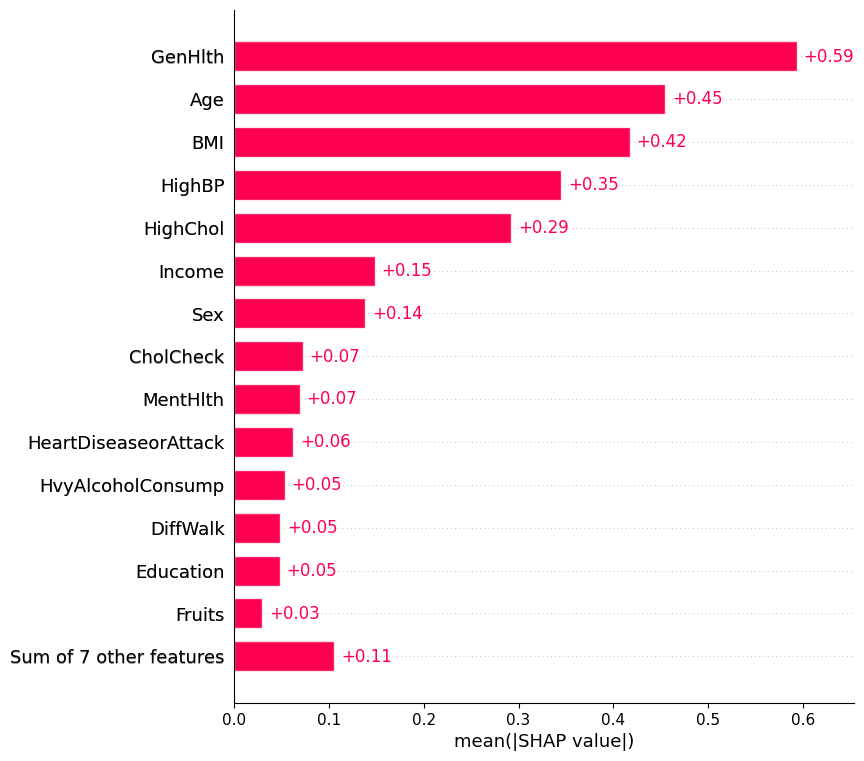

In [ ]:
shap.plots.bar(binary_xgb_shap_values, max_display=15)

### SHAP Beeswarm Plot

The SHAP beeswarm plot shows both feature importance and the direction of feature effects. Features appearing near the top have the strongest overall influence on model predictions.

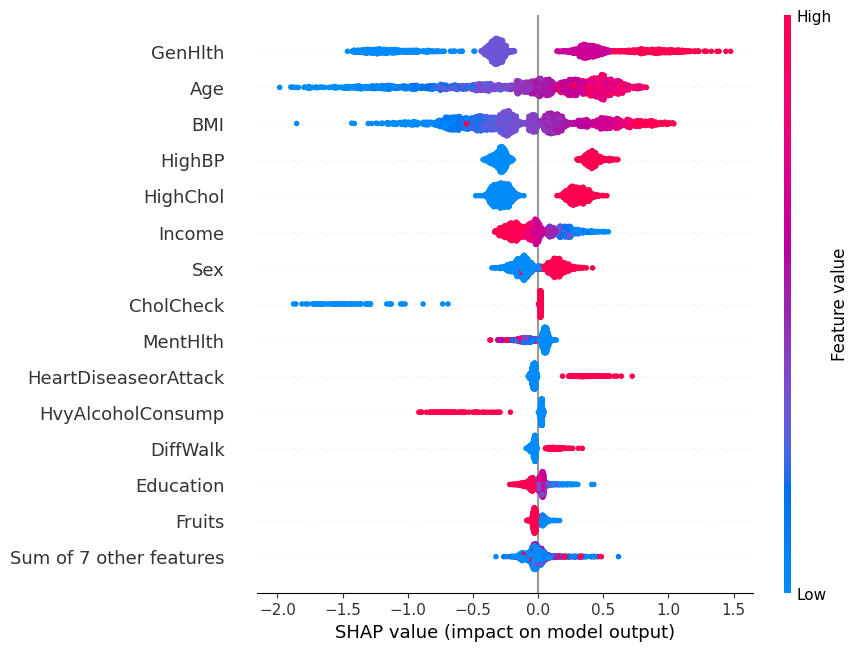

In [ ]:
shap.plots.beeswarm(binary_xgb_shap_values, max_display=15)

### Permutation Importance for Balanced Binary XGBoost

Permutation importance is used as a second explainability method to check whether the most influential SHAP features also affect predictive performance when shuffled.

In [ ]:
binary_xgb_perm_importance = compute_permutation_importance(
    model=binary_xgb_balanced_model,
    X_test=X_test_bin,
    y_test=y_test_bin,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

binary_xgb_perm_importance.head(15)

,feature,importance_mean,importance_std
13,GenHlth,0.040370,0.000709
3,BMI,0.028911,0.001041
18,Age,0.023577,0.001342
0,HighBP,0.009108,0.000892
1,HighChol,0.006858,0.000812
10,HvyAlcoholConsump,0.003377,0.000784
17,Sex,0.003187,0.000911
20,Income,0.002524,0.000741
2,CholCheck,0.002481,0.000804
16,DiffWalk,0.001816,0.000443


### Permutation Importance for Balanced Multiclass Logistic Regression

Permutation importance is also applied to the Balanced Logistic Regression multiclass model, using macro F1-score as the scoring metric. This helps identify which features most affect multiclass prediction performance.

In [ ]:
multiclass_lr_perm_importance = compute_permutation_importance(
    model=multiclass_lr_balanced_model,
    X_test=X_test_multi,
    y_test=y_test_multi,
    scoring="f1_macro",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

multiclass_lr_perm_importance.head(15)

,feature,importance_mean,importance_std
13,GenHlth,0.035375,0.001691
3,BMI,0.014890,0.000790
0,HighBP,0.013534,0.001099
18,Age,0.006387,0.001274
10,HvyAlcoholConsump,0.002891,0.000786
1,HighChol,0.001648,0.000519
20,Income,0.001647,0.000407
16,DiffWalk,0.001323,0.000155
2,CholCheck,0.001266,0.000403
6,HeartDiseaseorAttack,0.001030,0.000421


##  Feature Selection for Compact Screening Tool

The fourth research question examines whether a compact diabetes risk screening tool can be developed using a reduced set of BRFSS health indicators. To address this, four feature selection methods are applied:

1. SHAP-based ranking
2. LASSO-based feature selection
3. Recursive Feature Elimination (RFE)
4. Mutual Information

Each method identifies the top features according to a different selection principle. The selected features will later be used to train reduced-feature models and compare their performance with the full-feature models.

In [ ]:
from src.feature_selection import (
    get_top_shap_features,
    lasso_feature_selection,
    rfe_feature_selection,
    mutual_information_feature_selection,
    create_reduced_feature_dataset
)

### SHAP-Based Feature Ranking

The SHAP importance values computed from the Balanced XGBoost binary model are used to select the top-ranked predictors.

In [ ]:
top_shap_features = get_top_shap_features(
    shap_importance_df=binary_xgb_shap_importance,
    feature_col="feature",
    importance_col="mean_abs_shap",
    top_n=10
)

top_shap_features

['GenHlth',
 'Age',
 'BMI',
 'HighBP',
 'HighChol',
 'Income',
 'Sex',
 'CholCheck',
 'MentHlth',
 'HeartDiseaseorAttack']

### LASSO-Based Feature Selection

LASSO feature selection is performed using L1-regularized Logistic Regression. Features with larger absolute coefficients are considered more influential.

In [ ]:
lasso_features_df = lasso_feature_selection(
    X_train=X_train_bin,
    y_train=y_train_bin,
    top_n=10,
    random_state=42
)

lasso_features_df

,feature,lasso_importance
13,GenHlth,0.618336
3,BMI,0.490484
18,Age,0.457021
0,HighBP,0.364557
1,HighChol,0.287324
2,CholCheck,0.248931
10,HvyAlcoholConsump,0.173118
17,Sex,0.139249
20,Income,0.119407
6,HeartDiseaseorAttack,0.073103


### Recursive Feature Elimination

Recursive Feature Elimination is applied using Logistic Regression as the estimator. RFE repeatedly removes less important variables until the specified number of features remains.

In [ ]:
rfe_features_df = rfe_feature_selection(
    X_train=X_train_bin,
    y_train=y_train_bin,
    top_n=10,
    random_state=42
)

rfe_features_df

,feature,selected,rfe_rank
0,HighBP,True,1
1,HighChol,True,1
2,CholCheck,True,1
3,BMI,True,1
6,HeartDiseaseorAttack,True,1
10,HvyAlcoholConsump,True,1
13,GenHlth,True,1
17,Sex,True,1
18,Age,True,1
20,Income,True,1


### Mutual Information Feature Selection

Mutual Information is used to measure the dependency between each predictor and the binary diabetes target variable.

In [ ]:
mi_features_df = mutual_information_feature_selection(
    X_train=X_train_bin,
    y_train=y_train_bin,
    top_n=10,
    random_state=42
)

mi_features_df

,feature,mutual_information
13,GenHlth,0.052041
0,HighBP,0.050403
11,AnyHealthcare,0.042296
2,CholCheck,0.040522
7,PhysActivity,0.040289
1,HighChol,0.035923
9,Veggies,0.034248
8,Fruits,0.033370
3,BMI,0.028983
18,Age,0.023295


###  Extract Feature Lists from Each Method

In [ ]:
lasso_top_features = lasso_features_df["feature"].tolist()
rfe_top_features = rfe_features_df["feature"].tolist()
mi_top_features = mi_features_df["feature"].tolist()

print("Top SHAP Features:")
print(top_shap_features)

print("\nTop LASSO Features:")
print(lasso_top_features)

print("\nTop RFE Features:")
print(rfe_top_features)

print("\nTop Mutual Information Features:")
print(mi_top_features)

Top SHAP Features:
['GenHlth', 'Age', 'BMI', 'HighBP', 'HighChol', 'Income', 'Sex', 'CholCheck', 'MentHlth', 'HeartDiseaseorAttack']

Top LASSO Features:
['GenHlth', 'BMI', 'Age', 'HighBP', 'HighChol', 'CholCheck', 'HvyAlcoholConsump', 'Sex', 'Income', 'HeartDiseaseorAttack']

Top RFE Features:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'HeartDiseaseorAttack', 'HvyAlcoholConsump', 'GenHlth', 'Sex', 'Age', 'Income']

Top Mutual Information Features:
['GenHlth', 'HighBP', 'AnyHealthcare', 'CholCheck', 'PhysActivity', 'HighChol', 'Veggies', 'Fruits', 'BMI', 'Age']


### Create Reduced Feature Dataset Using SHAP Top Features

As an initial reduced-feature experiment, the top 10 SHAP-ranked features are used to create a compact predictor set. This reduced dataset will later be used to train and evaluate compact models.

In [ ]:
X_train_bin_shap10 = create_reduced_feature_dataset(
    X=X_train_bin,
    selected_features=top_shap_features
)

X_test_bin_shap10 = create_reduced_feature_dataset(
    X=X_test_bin,
    selected_features=top_shap_features
)

print("Reduced binary training shape:", X_train_bin_shap10.shape)
print("Reduced binary testing shape:", X_test_bin_shap10.shape)

Reduced binary training shape: (202944, 10)
Reduced binary testing shape: (50736, 10)


## Reduced-Feature Modeling for Compact Diabetes Screening

The fourth research question investigates whether a compact diabetes risk screening model can maintain performance using a reduced set of BRFSS health indicators.

Based on the SHAP feature ranking, the top 10 predictors are selected to create a reduced feature set. These features are used to retrain the strongest candidate models:

1. Balanced Logistic Regression
2. Balanced XGBoost

The reduced-feature models are then compared with their full-feature counterparts to evaluate whether fewer health indicators can provide comparable predictive performance.

In [ ]:
from src.reduced_models import (
    build_reduced_balanced_logistic_regression_model,
    build_reduced_balanced_xgboost_model,
    train_reduced_model
)

###  Selected Reduced Feature Set

In [ ]:
selected_shap10_features = top_shap_features

print("Selected SHAP Top 10 Features:")
for idx, feature in enumerate(selected_shap10_features, start=1):
    print(f"{idx}. {feature}")

Selected SHAP Top 10 Features:
1. GenHlth
2. Age
3. BMI
4. HighBP
5. HighChol
6. Income
7. Sex
8. CholCheck
9. MentHlth
10. HeartDiseaseorAttack


### Create Reduced Feature Sets for Binary and Multiclass Data

In [ ]:
X_train_bin_reduced = create_reduced_feature_dataset(
    X=X_train_bin,
    selected_features=selected_shap10_features
)

X_test_bin_reduced = create_reduced_feature_dataset(
    X=X_test_bin,
    selected_features=selected_shap10_features
)

X_train_multi_reduced = create_reduced_feature_dataset(
    X=X_train_multi,
    selected_features=selected_shap10_features
)

X_test_multi_reduced = create_reduced_feature_dataset(
    X=X_test_multi,
    selected_features=selected_shap10_features
)

print("Binary reduced train shape:", X_train_bin_reduced.shape)
print("Binary reduced test shape:", X_test_bin_reduced.shape)
print("Multiclass reduced train shape:", X_train_multi_reduced.shape)
print("Multiclass reduced test shape:", X_test_multi_reduced.shape)

Binary reduced train shape: (202944, 10)
Binary reduced test shape: (50736, 10)
Multiclass reduced train shape: (202944, 10)
Multiclass reduced test shape: (50736, 10)


###  Reduced Balanced Logistic Regression - Binary

In [ ]:
binary_lr_reduced_model = build_reduced_balanced_logistic_regression_model(
    task_type="binary",
    random_state=42,
    max_iter=1000
)

binary_lr_reduced_model = train_reduced_model(
    model=binary_lr_reduced_model,
    X_train=X_train_bin_reduced,
    y_train=y_train_bin
)

print("Reduced Binary Balanced Logistic Regression trained successfully.")

Reduced Binary Balanced Logistic Regression trained successfully.


In [ ]:
binary_lr_reduced_results = evaluate_binary_model(
    model=binary_lr_reduced_model,
    X_test=X_test_bin_reduced,
    y_test=y_test_bin
)

binary_lr_reduced_summary = summarize_results(binary_lr_reduced_results)

binary_lr_reduced_summary

,accuracy,precision,recall,f1_score,roc_auc
0,0.729167,0.308825,0.762343,0.439577,0.818022


In [ ]:
print("Reduced Binary Balanced Logistic Regression Classification Report:")
print(binary_lr_reduced_results["classification_report"])

print("Reduced Binary Balanced Logistic Regression Confusion Matrix:")
print(binary_lr_reduced_results["confusion_matrix"])

Reduced Binary Balanced Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.72      0.82     43667
         1.0       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736

Reduced Binary Balanced Logistic Regression Confusion Matrix:
[[31606 12061]
 [ 1680  5389]]


###  Reduced Balanced Logistic Regression - Multiclass

In [ ]:
multiclass_lr_reduced_model = build_reduced_balanced_logistic_regression_model(
    task_type="multiclass",
    random_state=42,
    max_iter=1000
)

multiclass_lr_reduced_model = train_reduced_model(
    model=multiclass_lr_reduced_model,
    X_train=X_train_multi_reduced,
    y_train=y_train_multi
)

print("Reduced Multiclass Balanced Logistic Regression trained successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Reduced Multiclass Balanced Logistic Regression trained successfully.


In [ ]:
multiclass_lr_reduced_results = evaluate_multiclass_model(
    model=multiclass_lr_reduced_model,
    X_test=X_test_multi_reduced,
    y_test=y_test_multi
)

multiclass_lr_reduced_summary = summarize_results(multiclass_lr_reduced_results)

multiclass_lr_reduced_summary

,accuracy,precision_macro,recall_macro,f1_macro
0,0.647725,0.443839,0.51787,0.425892


In [ ]:
print("Reduced Multiclass Balanced Logistic Regression Classification Report:")
print(multiclass_lr_reduced_results["classification_report"])

print("Reduced Multiclass Balanced Logistic Regression Confusion Matrix:")
print(multiclass_lr_reduced_results["confusion_matrix"])

Reduced Multiclass Balanced Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.67      0.78     42741
         1.0       0.03      0.30      0.06       926
         2.0       0.35      0.58      0.44      7069

    accuracy                           0.65     50736
   macro avg       0.44      0.52      0.43     50736
weighted avg       0.85      0.65      0.72     50736

Reduced Multiclass Balanced Logistic Regression Confusion Matrix:
[[28458  7050  7233]
 [  253   282   391]
 [ 1269  1677  4123]]


###  Reduced Balanced XGBoost - Binary

In [ ]:
binary_xgb_reduced_model = build_reduced_balanced_xgboost_model(
    task_type="binary",
    scale_pos_weight=binary_scale_pos_weight,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

binary_xgb_reduced_model = train_reduced_model(
    model=binary_xgb_reduced_model,
    X_train=X_train_bin_reduced,
    y_train=y_train_bin
)

print("Reduced Binary Balanced XGBoost trained successfully.")

Reduced Binary Balanced XGBoost trained successfully.


In [ ]:
binary_xgb_reduced_results = evaluate_binary_model(
    model=binary_xgb_reduced_model,
    X_test=X_test_bin_reduced,
    y_test=y_test_bin
)

binary_xgb_reduced_summary = summarize_results(binary_xgb_reduced_results)

binary_xgb_reduced_summary

,accuracy,precision,recall,f1_score,roc_auc
0,0.717558,0.303555,0.793606,0.439139,0.824805


In [ ]:
print("Reduced Binary Balanced XGBoost Classification Report:")
print(binary_xgb_reduced_results["classification_report"])

print("Reduced Binary Balanced XGBoost Confusion Matrix:")
print(binary_xgb_reduced_results["confusion_matrix"])

Reduced Binary Balanced XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.71      0.81     43667
         1.0       0.30      0.79      0.44      7069

    accuracy                           0.72     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.72      0.76     50736

Reduced Binary Balanced XGBoost Confusion Matrix:
[[30796 12871]
 [ 1459  5610]]


###  Reduced Balanced XGBoost - Multiclass

In [ ]:
multiclass_xgb_reduced_sample_weights = compute_multiclass_sample_weights(
    y_train_multi
)

multiclass_xgb_reduced_model = build_reduced_balanced_xgboost_model(
    task_type="multiclass",
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

multiclass_xgb_reduced_model = train_reduced_model(
    model=multiclass_xgb_reduced_model,
    X_train=X_train_multi_reduced,
    y_train=y_train_multi,
    sample_weight=multiclass_xgb_reduced_sample_weights
)

print("Reduced Multiclass Balanced XGBoost trained successfully.")

Reduced Multiclass Balanced XGBoost trained successfully.


In [ ]:
multiclass_xgb_reduced_results = evaluate_multiclass_model(
    model=multiclass_xgb_reduced_model,
    X_test=X_test_multi_reduced,
    y_test=y_test_multi
)

multiclass_xgb_reduced_summary = summarize_results(multiclass_xgb_reduced_results)

multiclass_xgb_reduced_summary

,accuracy,precision_macro,recall_macro,f1_macro
0,0.619639,0.442347,0.514893,0.416263


In [ ]:
print("Reduced Multiclass Balanced XGBoost Classification Report:")
print(multiclass_xgb_reduced_results["classification_report"])

print("Reduced Multiclass Balanced XGBoost Confusion Matrix:")
print(multiclass_xgb_reduced_results["confusion_matrix"])

Reduced Multiclass Balanced XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.63      0.76     42741
         1.0       0.03      0.31      0.05       926
         2.0       0.34      0.61      0.44      7069

    accuracy                           0.62     50736
   macro avg       0.44      0.51      0.42     50736
weighted avg       0.85      0.62      0.70     50736

Reduced Multiclass Balanced XGBoost Confusion Matrix:
[[26866  8116  7759]
 [  222   287   417]
 [ 1048  1736  4285]]


### Full-Feature versus Reduced-Feature Model Comparison

The reduced-feature models are compared with their corresponding full-feature models to determine whether compact models can maintain similar predictive performance using fewer BRFSS indicators.

In [ ]:
binary_reduced_comparison = pd.DataFrame({
    "model": [
        "Full Balanced Logistic Regression",
        "Reduced Balanced Logistic Regression",
        "Full Balanced XGBoost",
        "Reduced Balanced XGBoost"
    ],
    "features": [
        21,
        len(selected_shap10_features),
        21,
        len(selected_shap10_features)
    ],
    "accuracy": [
        binary_lr_balanced_summary["accuracy"].iloc[0],
        binary_lr_reduced_summary["accuracy"].iloc[0],
        binary_xgb_balanced_summary["accuracy"].iloc[0],
        binary_xgb_reduced_summary["accuracy"].iloc[0]
    ],
    "precision": [
        binary_lr_balanced_summary["precision"].iloc[0],
        binary_lr_reduced_summary["precision"].iloc[0],
        binary_xgb_balanced_summary["precision"].iloc[0],
        binary_xgb_reduced_summary["precision"].iloc[0]
    ],
    "recall": [
        binary_lr_balanced_summary["recall"].iloc[0],
        binary_lr_reduced_summary["recall"].iloc[0],
        binary_xgb_balanced_summary["recall"].iloc[0],
        binary_xgb_reduced_summary["recall"].iloc[0]
    ],
    "f1_score": [
        binary_lr_balanced_summary["f1_score"].iloc[0],
        binary_lr_reduced_summary["f1_score"].iloc[0],
        binary_xgb_balanced_summary["f1_score"].iloc[0],
        binary_xgb_reduced_summary["f1_score"].iloc[0]
    ],
    "roc_auc": [
        binary_lr_balanced_summary["roc_auc"].iloc[0],
        binary_lr_reduced_summary["roc_auc"].iloc[0],
        binary_xgb_balanced_summary["roc_auc"].iloc[0],
        binary_xgb_reduced_summary["roc_auc"].iloc[0]
    ]
})

binary_reduced_comparison

,model,features,accuracy,precision,recall,f1_score,roc_auc
0,Full Balanced Logistic Regression,21,0.731512,0.310749,0.761069,0.441309,0.819631
1,Reduced Balanced Logistic Regression,10,0.729167,0.308825,0.762343,0.439577,0.818022
2,Full Balanced XGBoost,21,0.721756,0.307115,0.793747,0.442875,0.827355
3,Reduced Balanced XGBoost,10,0.717558,0.303555,0.793606,0.439139,0.824805


In [ ]:
multiclass_reduced_comparison = pd.DataFrame({
    "model": [
        "Full Balanced Logistic Regression",
        "Reduced Balanced Logistic Regression",
        "Full Balanced XGBoost",
        "Reduced Balanced XGBoost"
    ],
    "features": [
        21,
        len(selected_shap10_features),
        21,
        len(selected_shap10_features)
    ],
    "accuracy": [
        multiclass_lr_balanced_summary["accuracy"].iloc[0],
        multiclass_lr_reduced_summary["accuracy"].iloc[0],
        multiclass_xgb_balanced_summary["accuracy"].iloc[0],
        multiclass_xgb_reduced_summary["accuracy"].iloc[0]
    ],
    "precision_macro": [
        multiclass_lr_balanced_summary["precision_macro"].iloc[0],
        multiclass_lr_reduced_summary["precision_macro"].iloc[0],
        multiclass_xgb_balanced_summary["precision_macro"].iloc[0],
        multiclass_xgb_reduced_summary["precision_macro"].iloc[0]
    ],
    "recall_macro": [
        multiclass_lr_balanced_summary["recall_macro"].iloc[0],
        multiclass_lr_reduced_summary["recall_macro"].iloc[0],
        multiclass_xgb_balanced_summary["recall_macro"].iloc[0],
        multiclass_xgb_reduced_summary["recall_macro"].iloc[0]
    ],
    "f1_macro": [
        multiclass_lr_balanced_summary["f1_macro"].iloc[0],
        multiclass_lr_reduced_summary["f1_macro"].iloc[0],
        multiclass_xgb_balanced_summary["f1_macro"].iloc[0],
        multiclass_xgb_reduced_summary["f1_macro"].iloc[0]
    ]
})

multiclass_reduced_comparison

,model,features,accuracy,precision_macro,recall_macro,f1_macro
0,Full Balanced Logistic Regression,21,0.645754,0.445639,0.524173,0.426883
1,Reduced Balanced Logistic Regression,10,0.647725,0.443839,0.517870,0.425892
2,Full Balanced XGBoost,21,0.624152,0.443809,0.523070,0.419565
3,Reduced Balanced XGBoost,10,0.619639,0.442347,0.514893,0.416263


## Hyperparameter Tuning of Selected Final Models

The proposal stated that model hyperparameters would be tuned using cross-validation. Since the earlier experiments already identified the strongest candidate models, hyperparameter tuning is applied only to selected final models rather than every baseline model.


The selected models are:

1. Balanced XGBoost for binary classification
2. Balanced Logistic Regression for multiclass classification
3. Balanced XGBoost for multiclass classification

RandomizedSearchCV is used instead of exhaustive GridSearchCV to reduce computational cost.

In [ ]:
from src.hyperparameter_tuning import (
    tune_model_randomized_search,
    get_best_model_from_search,
    summarize_tuning_results
)

### Tune Balanced Binary XGBoost

In [ ]:
from src.xgboost_balanced import (
    build_balanced_binary_xgboost_model,
    calculate_binary_scale_pos_weight
)

binary_scale_pos_weight = calculate_binary_scale_pos_weight(y_train_bin)

binary_xgb_tuning_model = build_balanced_binary_xgboost_model(
    scale_pos_weight=binary_scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

binary_xgb_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

binary_xgb_search = tune_model_randomized_search(
    model=binary_xgb_tuning_model,
    param_distributions=binary_xgb_param_dist,
    X_train=X_train_bin,
    y_train=y_train_bin,
    scoring="f1",
    n_iter=15,
    cv_splits=3,
    random_state=42,
    n_jobs=-1
)

summarize_tuning_results(binary_xgb_search)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,best_cv_score,best_params
0,0.443383,"{'subsample': 1.0, 'n_estimators': 200, 'max_d..."


In [ ]:
binary_xgb_tuned_model = get_best_model_from_search(binary_xgb_search)

binary_xgb_tuned_results = evaluate_binary_model(
    model=binary_xgb_tuned_model,
    X_test=X_test_bin,
    y_test=y_test_bin
)

binary_xgb_tuned_summary = summarize_results(binary_xgb_tuned_results)
binary_xgb_tuned_summary

,accuracy,precision,recall,f1_score,roc_auc
0,0.7215,0.306813,0.793181,0.442472,0.827117


In [ ]:
print("Tuned Balanced Binary XGBoost Classification Report:")
print(binary_xgb_tuned_results["classification_report"])

print("Tuned Balanced Binary XGBoost Confusion Matrix:")
print(binary_xgb_tuned_results["confusion_matrix"])

Tuned Balanced Binary XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.71      0.81     43667
         1.0       0.31      0.79      0.44      7069

    accuracy                           0.72     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.72      0.76     50736

Tuned Balanced Binary XGBoost Confusion Matrix:
[[30999 12668]
 [ 1462  5607]]


###  Tune Balanced Multiclass Logistic Regression

In [ ]:
from src.reduced_models import build_reduced_balanced_logistic_regression_model

multiclass_lr_tuning_model = build_reduced_balanced_logistic_regression_model(
    task_type="multiclass",
    random_state=42,
    max_iter=2000
)

multiclass_lr_param_dist = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0],
    "classifier__solver": ["lbfgs"],
    "classifier__max_iter": [1000, 2000]
}

multiclass_lr_search = tune_model_randomized_search(
    model=multiclass_lr_tuning_model,
    param_distributions=multiclass_lr_param_dist,
    X_train=X_train_multi,
    y_train=y_train_multi,
    scoring="f1_macro",
    n_iter=8,
    cv_splits=3,
    random_state=42,
    n_jobs=-1
)

summarize_tuning_results(multiclass_lr_search)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,best_cv_score,best_params
0,0.425915,"{'classifier__solver': 'lbfgs', 'classifier__m..."


In [ ]:
multiclass_lr_tuned_model = get_best_model_from_search(multiclass_lr_search)

multiclass_lr_tuned_results = evaluate_multiclass_model(
    model=multiclass_lr_tuned_model,
    X_test=X_test_multi,
    y_test=y_test_multi
)

multiclass_lr_tuned_summary = summarize_results(multiclass_lr_tuned_results)
multiclass_lr_tuned_summary

,accuracy,precision_macro,recall_macro,f1_macro
0,0.645814,0.445681,0.524275,0.426941


In [ ]:
print("Tuned Balanced Multiclass Logistic Regression Classification Report:")
print(multiclass_lr_tuned_results["classification_report"])

print("Tuned Balanced Multiclass Logistic Regression Confusion Matrix:")
print(multiclass_lr_tuned_results["confusion_matrix"])

Tuned Balanced Multiclass Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.66      0.78     42741
         1.0       0.03      0.33      0.06       926
         2.0       0.35      0.58      0.44      7069

    accuracy                           0.65     50736
   macro avg       0.45      0.52      0.43     50736
weighted avg       0.85      0.65      0.72     50736

Tuned Balanced Multiclass Logistic Regression Confusion Matrix:
[[28338  7237  7166]
 [  239   302   385]
 [ 1218  1725  4126]]


###  Tune Balanced Multiclass XGBoost

In [ ]:
from src.xgboost_balanced import (
    build_balanced_multiclass_xgboost_model,
    compute_multiclass_sample_weights
)

multiclass_sample_weights = compute_multiclass_sample_weights(y_train_multi)

multiclass_xgb_tuning_model = build_balanced_multiclass_xgboost_model(
    random_state=42,
    n_jobs=-1
)

multiclass_xgb_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

multiclass_xgb_search = RandomizedSearchCV(
    estimator=multiclass_xgb_tuning_model,
    param_distributions=multiclass_xgb_param_dist,
    n_iter=15,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2 # Increased verbosity for clearer output
)

multiclass_xgb_search.fit(
    X_train_multi,
    y_train_multi,
    sample_weight=multiclass_sample_weights
)

summarize_tuning_results(multiclass_xgb_search)
print("Multiclass XGBoost hyperparameter tuning completed successfully.")

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,best_cv_score,best_params
0,0.422085,"{'subsample': 0.8, 'n_estimators': 100, 'max_d..."


In [ ]:
multiclass_xgb_tuned_model = get_best_model_from_search(multiclass_xgb_search)

multiclass_xgb_tuned_results = evaluate_multiclass_model(
    model=multiclass_xgb_tuned_model,
    X_test=X_test_multi,
    y_test=y_test_multi
)

multiclass_xgb_tuned_summary = summarize_results(multiclass_xgb_tuned_results)
multiclass_xgb_tuned_summary

,accuracy,precision_macro,recall_macro,f1_macro
0,0.628883,0.443946,0.520649,0.421171


In [ ]:
print("Tuned Balanced Multiclass XGBoost Classification Report:")
print(multiclass_xgb_tuned_results["classification_report"])

print("Tuned Balanced Multiclass XGBoost Confusion Matrix:")
print(multiclass_xgb_tuned_results["confusion_matrix"])

Tuned Balanced Multiclass XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.64      0.76     42741
         1.0       0.03      0.30      0.05       926
         2.0       0.35      0.62      0.45      7069

    accuracy                           0.63     50736
   macro avg       0.44      0.52      0.42     50736
weighted avg       0.85      0.63      0.71     50736

Tuned Balanced Multiclass XGBoost Confusion Matrix:
[[27234  7675  7832]
 [  225   281   420]
 [ 1054  1623  4392]]


###  Tuned versus Previous Best Models

In [ ]:
binary_tuning_comparison = pd.DataFrame({
    "model": [
        "Balanced XGBoost",
        "Tuned Balanced XGBoost"
    ],
    "accuracy": [
        binary_xgb_balanced_summary["accuracy"].iloc[0],
        binary_xgb_tuned_summary["accuracy"].iloc[0]
    ],
    "precision": [
        binary_xgb_balanced_summary["precision"].iloc[0],
        binary_xgb_tuned_summary["precision"].iloc[0]
    ],
    "recall": [
        binary_xgb_balanced_summary["recall"].iloc[0],
        binary_xgb_tuned_summary["recall"].iloc[0]
    ],
    "f1_score": [
        binary_xgb_balanced_summary["f1_score"].iloc[0],
        binary_xgb_tuned_summary["f1_score"].iloc[0]
    ],
    "roc_auc": [
        binary_xgb_balanced_summary["roc_auc"].iloc[0],
        binary_xgb_tuned_summary["roc_auc"].iloc[0]
    ]
})

binary_tuning_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
0,Balanced XGBoost,0.721756,0.307115,0.793747,0.442875,0.827355
1,Tuned Balanced XGBoost,0.721500,0.306813,0.793181,0.442472,0.827117


In [ ]:
multiclass_tuning_comparison = pd.DataFrame({
    "model": [
        "Balanced Logistic Regression",
        "Tuned Balanced Logistic Regression",
        "Balanced XGBoost",
        "Tuned Balanced XGBoost"
    ],
    "accuracy": [
        multiclass_lr_balanced_summary["accuracy"].iloc[0],
        multiclass_lr_tuned_summary["accuracy"].iloc[0],
        multiclass_xgb_balanced_summary["accuracy"].iloc[0],
        multiclass_xgb_tuned_summary["accuracy"].iloc[0]
    ],
    "precision_macro": [
        multiclass_lr_balanced_summary["precision_macro"].iloc[0],
        multiclass_lr_tuned_summary["precision_macro"].iloc[0],
        multiclass_xgb_balanced_summary["precision_macro"].iloc[0],
        multiclass_xgb_tuned_summary["precision_macro"].iloc[0]
    ],
    "recall_macro": [
        multiclass_lr_balanced_summary["recall_macro"].iloc[0],
        multiclass_lr_tuned_summary["recall_macro"].iloc[0],
        multiclass_xgb_balanced_summary["recall_macro"].iloc[0],
        multiclass_xgb_tuned_summary["recall_macro"].iloc[0]
    ],
    "f1_macro": [
        multiclass_lr_balanced_summary["f1_macro"].iloc[0],
        multiclass_lr_tuned_summary["f1_macro"].iloc[0],
        multiclass_xgb_balanced_summary["f1_macro"].iloc[0],
        multiclass_xgb_tuned_summary["f1_macro"].iloc[0]
    ]
})

multiclass_tuning_comparison

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Balanced Logistic Regression,0.645754,0.445639,0.524173,0.426883
1,Tuned Balanced Logistic Regression,0.645814,0.445681,0.524275,0.426941
2,Balanced XGBoost,0.624152,0.443809,0.523070,0.419565
3,Tuned Balanced XGBoost,0.628883,0.443946,0.520649,0.421171
